# Offshore wind NPV simulation

Run the offshore wind electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_npv_monte_carlo import simulate_wind_offshore_npv


In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_wind_offshore_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,3061.061351,41.010633,8.632859,0.0,...,94070000.0,1.065211e+07,8.632859e+06,0.0,0.0,7.478503e+07,3.232568e+06,25000000.0,0.129303,1.293027e-07
1,1,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,3028.057418,37.090076,8.136705,0.0,...,94070000.0,9.633786e+06,8.136705e+06,0.0,0.0,7.629951e+07,2.797177e+07,25000000.0,1.118871,1.118871e-06
2,2,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,2433.126818,46.410931,8.226979,0.0,...,94070000.0,1.205479e+07,8.226979e+06,0.0,0.0,7.378823e+07,1.556919e+08,25000000.0,6.227676,6.227676e-06
3,3,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,2880.586277,43.201817,6.577908,0.0,...,94070000.0,1.122125e+07,6.577908e+06,0.0,0.0,7.627084e+07,6.596993e+07,25000000.0,2.638797,2.638797e-06
4,4,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,2205.749298,38.242577,7.253441,0.0,...,94070000.0,9.933137e+06,7.253441e+06,0.0,0.0,7.688342e+07,2.477914e+08,25000000.0,9.911657,9.911657e-06


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,77.045527,3.081821,0.000003
std,91.112643,3.644506,0.000004
min,-124.951412,-4.998056,-0.000005
5%,-64.412285,-2.576491,-0.000003
50%,77.031529,3.081261,0.000003
95%,218.534693,8.741388,0.000009
max,273.730909,10.949236,0.000011


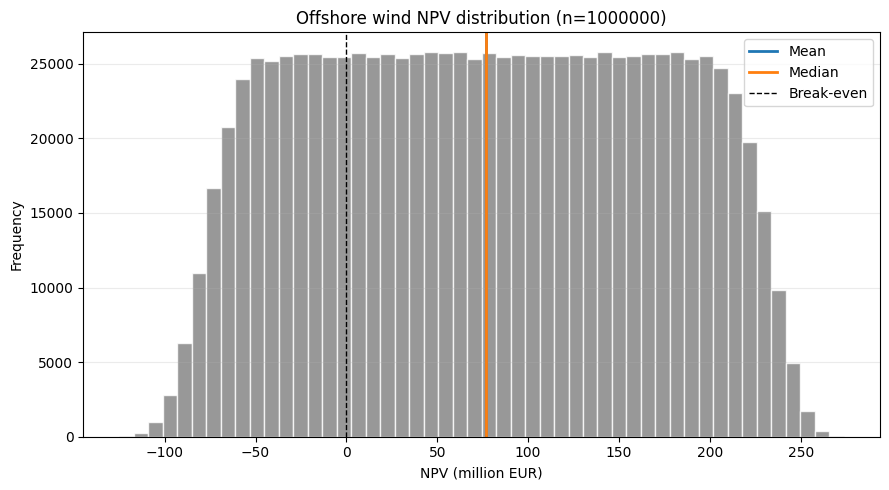

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Offshore wind NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


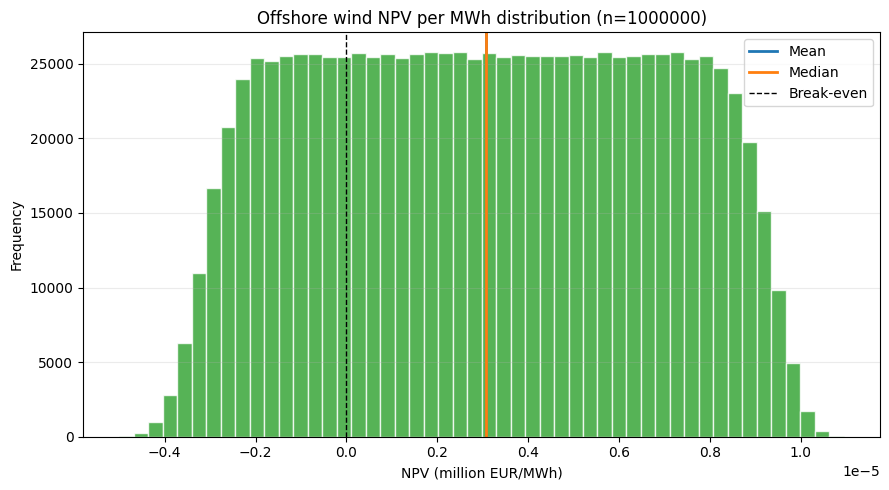

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Offshore wind NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        10.466929
annual_variable_opex_eur      8.265450
annual_fuel_cost_eur          0.000000
annual_emissions_cost_eur     0.000000
annual_net_cash_flow_eur     75.337621
Name: Mean annual value, million EUR, dtype: float64